In [1]:
from pathlib import Path
import os

import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import tqdm

from gena_expression.conditions import Condition, DescriptionLookup
from gena_expression.dna import Genome, GenomeRegion, GenomeContext, PlasmidContext
from gena_expression.inference import SequenceModel
from gena_expression.scoring import VariantInterpreter
from gena_expression.scoring import (
    ExpressionDeltaScorer,
    TrackWindowScorer,
    TrackFeatureScorer,
    TrackAllFeaturesScorer
)
from gena_expression.scoring import ScoringResult
from gena_expression.sequences import AnnotatedSequence, Feature, SequencePair
from gena_expression.variants import Variant
from gena_expression.dna import PlasmidRecord, infer_table18_primer_tails, PlasmidCollection
from notebook_utils.cagi5_helpers.CONST import table18_primers, locations, enhancer_to_mpra_plasmid, promoter_to_mpra_plasmid
from notebook_utils.cagi5_helpers.transcript_tss_annotation import add_same_strand_transcript_tss
from notebook_utils.cagi5_helpers.results_utils import ScoringResultsVisualizer


from typing import Any, Literal, Mapping, Sequence

In [2]:
API_ROOT = Path("/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api")
DATA_DIR = API_ROOT / "data"

MPRA_TABLE = DATA_DIR / "mpra_cagi5" / "Kircher_GRCh38_ALL.tsv"
DESCRIPTION_DIR = DATA_DIR / "rna_seq_generated_descriptions"
#DESCRIPTION_DIR = DATA_DIR / "atacseq_generated_descriptions"

PLASMID_DIR = DATA_DIR / "plasmids"

GENOME_FASTA = Path("/home/jovyan/.cache/mpramnist/data/Kircher/hg38.fa")
GENOME_ANNOTATION = Path(
    "/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/"
    "downstream_tasks/expression_prediction/datasets/data/genomes/hg38/"
    "gencode.v29.primary_assembly.annotation_UCSC_names.gtf"
)

DEVICE = "cuda:6"
os.environ["GENALM_HOME"] = Path('../../../../..').resolve().__str__()

ROOT = Path("/workspace-SR003.nfs2/estsoi/CAGI5_benchmark")
GENA_LM_ROOT = ROOT / "GENA_LM"
EXPRESSION_TASK_DIR = GENA_LM_ROOT / "downstream_tasks" / "expression_prediction"

MODEL_CLS_PATH = EXPRESSION_TASK_DIR / "expression_model_final.py"
MODEL_CLS = f"{MODEL_CLS_PATH}::ExpressionCounts"

#MODEL_CHECKPOINT = ROOT / "models" / "expression_model_latest" / "pytorch_model.bin"
MODEL_CHECKPOINT = ROOT / "models" / "expression_model_v1-1" / "pytorch_model.bin"
#MODEL_CONFIG = EXPRESSION_TASK_DIR / "inference_example_config.yaml"
MODEL_CONFIG = EXPRESSION_TASK_DIR / 'configs' / "final.yaml"
DNA_TOKENIZER = GENA_LM_ROOT / "data" / "tokenizers" / "t2t_1000h_multi_32k"
DESCRIPTION_TOKENIZER = "Qwen/Qwen3-Embedding-0.6B"

In [3]:
ENHANCERS_CELL_TYPES = {
    "HEK293T","HEL92.1.7",
    "HaCaT", "HeLa",
    "HepG2", "K562",
    "LNCaP", "MIN6",
    "NIH-3T3", "Neuro-2a",
    "SF7996", "SK-MEL-28",
}
PROMOTERS_CELL_TYPE = {
    "HEK293T", "HEL92.1.7",
    "HaCaT", "HeLa",
    "HepG2", "K562",
    "LNCaP", "MIN6",
    "NIH-3T3", "Neuro-2a",
    "SF7996", "SK-MEL-28",
}
ALL_CELL_TYPES = list(ENHANCERS_CELL_TYPES | PROMOTERS_CELL_TYPE)

ELEMENT_TO_PLASMID = enhancer_to_mpra_plasmid | promoter_to_mpra_plasmid

In [4]:
genome = Genome(
    fasta_path=GENOME_FASTA,
    annotation=GENOME_ANNOTATION,
)

/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/dna/genome.py:437: RuntimeWarning: Plain GTF/GFF annotations are not supported directly for fast interval queries; using existing compressed annotation /workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/genomes/hg38/gencode.v29.primary_assembly.annotation_UCSC_names.gtf.gz. debug={'plain_path': '/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/genomes/hg38/gencode.v29.primary_assembly.annotation_UCSC_names.gtf', 'compressed_path': '/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/genomes/hg38/gencode.v29.primary_assembly.annotation_UCSC_names.gtf.gz'}
  return _TabixGtfAnnotation(cls._ensure_tabix_gtf(path))
/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_

In [5]:
lookup = DescriptionLookup(
    json_dir=DESCRIPTION_DIR,
    keys=ALL_CELL_TYPES
)

conditions = {
    name: Condition(name=name, description=lookup[name])
    for name in lookup.keys()
}

In [6]:
dataset = pl.read_csv(
    MPRA_TABLE,
    separator="\t",
    infer_schema_length=10_000,
)

dataset = dataset.filter(pl.col.Tags>10).with_columns(
    (
        pl.lit("chr")
        + pl.col("Chromosome").cast(pl.String)
        + pl.lit(":")
        + pl.col("Position").cast(pl.String)
        + pl.lit(":")
        + pl.col("Ref").cast(pl.String)
        + pl.lit(">")
        + pl.col("Alt").cast(pl.String)
    ).alias("variant")
)

In [7]:
dataset['Element'].unique().to_list()

['IRF6',
 'SORT1',
 'TCF7L2',
 'MYCrs11986220',
 'BCL11A',
 'TERT-HEK',
 'ZRSh-13',
 'HNF4A',
 'PKLR-24h',
 'TERT-GAa',
 'MSMB',
 'LDLR',
 'HBG1',
 'ZFAND3',
 'FOXE1',
 'SORT1-flip',
 'LDLR.2',
 'IRF4',
 'GP1BA',
 'TERT-GSc',
 'HBB',
 'ZRSh-13h2',
 'F9',
 'SORT1.2',
 'RET',
 'UC88',
 'PKLR-48h',
 'MYCrs6983267',
 'TERT-GBM']

In [8]:
dataset = dataset.filter(pl.col.Element == 'LDLR')

In [9]:
dataset

Element,Cell_Type,Chromosome,Position,Ref,Alt,Tags,DNA,RNA,Value,P-Value,variant
str,str,str,i64,str,str,i64,i64,i64,f64,f64,str
"""LDLR""","""HepG2""","""19""",11089230,"""A""","""C""",27,1779,595,-0.13,0.45403,"""chr19:11089230:A>C"""
"""LDLR""","""HepG2""","""19""",11089230,"""A""","""G""",49,3576,1837,0.0,0.99402,"""chr19:11089230:A>G"""
"""LDLR""","""HepG2""","""19""",11089230,"""A""","""T""",232,21243,8589,0.0,0.95862,"""chr19:11089230:A>T"""
"""LDLR""","""HepG2""","""19""",11089231,"""G""","""A""",611,44390,17899,0.05,0.16605,"""chr19:11089231:G>A"""
"""LDLR""","""HepG2""","""19""",11089231,"""G""","""C""",128,6338,2409,-0.2,0.01546,"""chr19:11089231:G>C"""
…,…,…,…,…,…,…,…,…,…,…,…
"""LDLR""","""HepG2""","""19""",11089546,"""G""","""C""",544,47963,18008,-0.04,0.28008,"""chr19:11089546:G>C"""
"""LDLR""","""HepG2""","""19""",11089546,"""G""","""T""",205,22494,8618,0.02,0.7048,"""chr19:11089546:G>T"""
"""LDLR""","""HepG2""","""19""",11089547,"""C""","""A""",126,14739,5215,-0.04,0.61217,"""chr19:11089547:C>A"""


In [10]:
sequence_pairs : Sequence[SequencePair] = []
conditions = []
for element, cell_type, variant in tqdm.tqdm(dataset.select('Element', 'Cell_Type', 'variant').iter_rows(), total=dataset.__len__()):
    variant = Variant.from_str(variant, genome = genome, coordinate_system='0-based')
    variant.validate(genome=genome)
    sequence_pair = variant.to_sequence_pair(genome=genome,
                                             window_bp=20_000)
    condition = Condition(name=cell_type, description=lookup[cell_type])
    sequence_pairs.append(sequence_pair)
    conditions.append(condition)

100%|██████████| 1001/1001 [00:03<00:00, 262.97it/s]


In [14]:
sequence_pairs_processed = add_same_strand_transcript_tss(sequence_pairs=sequence_pairs, max_workers=1, max_distance=2_000, window=101, min_tss_dist=100)

Adding same-strand transcript TSSs: 100%|██████████| 1001/1001 [00:00<00:00, 2246.62it/s]


(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'chr19:11089231:G>C'}, xlabel='Sequence coordinate'>)

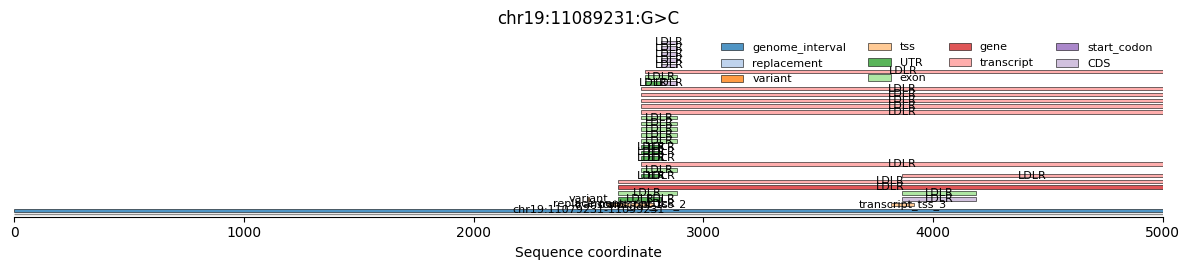

In [15]:
sequence_pairs_processed[4].alt.window(center=10_000, size=5000).plot_annotations()

In [16]:
sequence_pairs_processed[1].ref.feature_frame()

,name,start,end,type,strand,source,metadata
0,chr19:11079230-11099230,0,20000,genome_interval,+,genome,"{'chrom': 'chr19', 'start': 11079230, 'end': 1..."
1,SMARCA4,0,196,gene,+,HAVANA,"{'chrom': 'chr19', 'genomic_start': 10960824, ..."
2,SMARCA4,0,196,transcript,+,HAVANA,"{'chrom': 'chr19', 'genomic_start': 11030798, ..."
3,SMARCA4,0,196,exon,+,HAVANA,"{'chrom': 'chr19', 'genomic_start': 11078996, ..."
4,SMARCA4,0,196,UTR,+,HAVANA,"{'chrom': 'chr19', 'genomic_start': 11079104, ..."
5,LDLR,10131,10318,UTR,+,HAVANA,"{'chrom': 'chr19', 'genomic_start': 11089361, ..."
6,LDLR,10131,10385,exon,+,HAVANA,"{'chrom': 'chr19', 'genomic_start': 11089361, ..."
7,LDLR,10131,20000,transcript,+,HAVANA,"{'chrom': 'chr19', 'genomic_start': 11089361, ..."
8,LDLR,10131,20000,gene,+,HAVANA,"{'chrom': 'chr19', 'genomic_start': 11089361, ..."
9,LDLR,10231,10318,UTR,+,HAVANA,"{'chrom': 'chr19', 'genomic_start': 11089461, ..."


In [12]:
model = SequenceModel.load(
    model_cls=MODEL_CLS,
    checkpoint=MODEL_CHECKPOINT,
    config=MODEL_CONFIG,
    dna_tokenizer=DNA_TOKENIZER,
    description_tokenizer=DESCRIPTION_TOKENIZER,
    dna_max_seq_len=1024,
    num_before=511,
    desc_max_seq_len=510,
    token_len_for_fetch=100,
    device=DEVICE,
)

interpreter = VariantInterpreter(model)

/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/inference/model.py:162: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):
Flash Attention 2 only supports torch.float16 and torch.bfloat16 dtypes, but the current dype in ModernBertModel is torch.float32. You should run training or inference using Automatic Mixed-Precision via the `with torch.autocast(device_type='torch_device'):` decorator, or load the model with the `torch_dtype` argument. Example: `model = AutoModel.from_pretrained("openai/whisper-tiny", attn_implementation="flash_attention_2", torch_dtype=torch.float16)`


Using ModernGENA from /workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/modernbert_large
missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_pr

In [90]:
expression_delta_scorer = ExpressionDeltaScorer()



#Window scorers, tss and variant
track_scorer_tss_501bp = TrackWindowScorer(
    track="atac",
    center="reporter_tss",
    width_bp=501,
    aggregate="sum",
    sign="alt-ref",
    channel=0,
    name='track_window_501bp_tss'
)
track_scorer_variant_501bp = TrackWindowScorer(
                track="atac",
                center="variant",
                width_bp=501,
                aggregate="sum",
                sign="alt-ref",
                channel=0,
                name='track_window_501bp_variant'
                        )

track_scorer_tss_201bp = TrackWindowScorer(
    track="atac",
    center="reporter_tss",
    width_bp=201,
    aggregate="sum",
    sign="alt-ref",
    channel=0,
    name='track_window_201bp_tss'
)
track_scorer_variant_201bp = TrackWindowScorer(
                track="atac",
                center="variant",
                width_bp=201,
                aggregate="sum",
                sign="alt-ref",
                channel=0,
                name='track_window_201bp_variant'
                        ),

track_scorer_tss_101bp = TrackWindowScorer(
    track="atac",
    center="reporter_tss",
    width_bp=101,
    aggregate="sum",
    sign="alt-ref",
    channel=0,
    name='track_window_101bp_tss'
)
track_scorer_variant_101bp = TrackWindowScorer(
                track="atac",
                center="variant",
                width_bp=101,
                aggregate="sum",
                sign="alt-ref",
                channel=0,
                name='track_window_101bp_variant'
                        )

expression_delta_scorer = ExpressionDeltaScorer(),
scorer=TrackWindowScorer(
                track="atac",
                center="nearest_transcript_tss",
                width_bp=501,
                aggregate="sum",
                sign="alt-ref",
                channel=0,
                name='track_window'
                        ),
scorer = TrackWindowScorer(
                track="atac",
                center="variant",
                width_bp=501,
                aggregate="sum",
                sign="alt-ref",
                channel=0,
                name='track_window'
                        ),

In [13]:
import logging

logging.basicConfig(level=logging.INFO)

In [23]:
lookup = DescriptionLookup(
    json_dir='/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/metadata',
    keys=['ENCFF024KOW', 'ENCFF015XFX', 'ENCFF011DHD', 'ENCFF016TZA']
)

conditions = {
    name: Condition(name=name, description=lookup[name])
    for name in lookup.keys()
}

(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'chr19:11089230:A>C'}, xlabel='Sequence coordinate'>)

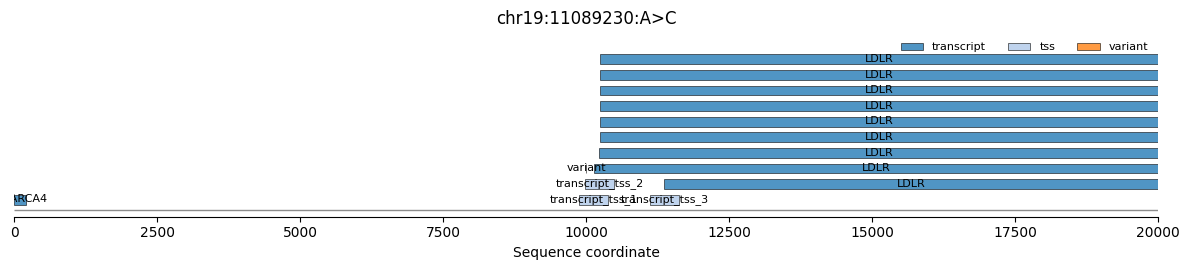

In [14]:
sequence_pairs_processed[0].ref.plot_annotations(types=['tss', 'transcript', 'variant'])

In [13]:
sequence_pairs_processed[2].ref.feature_frame()

,name,start,end,type,strand,source,metadata
0,chr19:11079230-11099230,0,20000,genome_interval,+,genome,"{'chrom': 'chr19', 'start': 11079230, 'end': 1..."
1,SMARCA4,0,196,gene,+,HAVANA,"{'chrom': 'chr19', 'genomic_start': 10960824, ..."
2,SMARCA4,0,196,transcript,+,HAVANA,"{'chrom': 'chr19', 'genomic_start': 11030798, ..."
3,SMARCA4,0,196,exon,+,HAVANA,"{'chrom': 'chr19', 'genomic_start': 11078996, ..."
4,SMARCA4,0,196,UTR,+,HAVANA,"{'chrom': 'chr19', 'genomic_start': 11079104, ..."
5,LDLR,10131,10318,UTR,+,HAVANA,"{'chrom': 'chr19', 'genomic_start': 11089361, ..."
6,LDLR,10131,10385,exon,+,HAVANA,"{'chrom': 'chr19', 'genomic_start': 11089361, ..."
7,LDLR,10131,20000,transcript,+,HAVANA,"{'chrom': 'chr19', 'genomic_start': 11089361, ..."
8,LDLR,10131,20000,gene,+,HAVANA,"{'chrom': 'chr19', 'genomic_start': 11089361, ..."
9,LDLR,10231,10318,UTR,+,HAVANA,"{'chrom': 'chr19', 'genomic_start': 11089461, ..."


In [28]:
tfs = TrackFeatureScorer(features=['transcript_tss_1', 'transcript_tss_2', 'transcript_tss_3'])
tws = TrackWindowScorer(
                    track="atac",
                    center="nearest_transcript_tss",
                    width_bp=501,
                    aggregate="sum",
                    sign="alt-ref",
                    channel=0,
                    name='track_window'
                            )
from gena_expression.scoring.scorers import TrackEffectPeakScorer

tefps = TrackEffectPeakScorer(max_points=5, direction='any', min_effect_fraction=0.2, window_bp=301, min_distance_bp=700, smoothing_bp=None, search_width_bp=4000)

In [29]:
results = interpreter.score_sequence_pairs(
    pairs=sequence_pairs_processed,
    conditions=conditions,
    scorer=tefps,
    grouping="no_grouping",
    max_pairs_per_forward=200,
    preprocessing_workers=5,
    prefetch_batches=2,
    show_progress=True,
    pair_execution='joint',
    center='transcript_tss_1'
)

Predicting allele pairs:   0%|          | 0/6 [00:00<?, ?batch/s]

Scoring track_effect_peaks: 100%|██████████| 1001/1001 [00:16<00:00, 61.04pair/s]


In [19]:
results[0].prediction.ref.sequence.feature_frame()

,name,start,end,type,strand,source,metadata
0,chr19:11079230-11099230,0,20000,genome_interval,+,genome,"{'chrom': 'chr19', 'start': 11079230, 'end': 1..."
1,SMARCA4,0,196,gene,+,HAVANA,"{'chrom': 'chr19', 'genomic_start': 10960824, ..."
2,SMARCA4,0,196,transcript,+,HAVANA,"{'chrom': 'chr19', 'genomic_start': 11030798, ..."
3,SMARCA4,0,196,exon,+,HAVANA,"{'chrom': 'chr19', 'genomic_start': 11078996, ..."
4,SMARCA4,0,196,UTR,+,HAVANA,"{'chrom': 'chr19', 'genomic_start': 11079104, ..."
5,LDLR,10131,10318,UTR,+,HAVANA,"{'chrom': 'chr19', 'genomic_start': 11089361, ..."
6,LDLR,10131,10385,exon,+,HAVANA,"{'chrom': 'chr19', 'genomic_start': 11089361, ..."
7,LDLR,10131,20000,transcript,+,HAVANA,"{'chrom': 'chr19', 'genomic_start': 11089361, ..."
8,LDLR,10131,20000,gene,+,HAVANA,"{'chrom': 'chr19', 'genomic_start': 11089361, ..."
9,LDLR,10231,10318,UTR,+,HAVANA,"{'chrom': 'chr19', 'genomic_start': 11089461, ..."


In [20]:
len(dataset)

1001

In [30]:
visualizer = ScoringResultsVisualizer(results = results, dataset=dataset, reverse_results=None)

In [31]:
visualizer.prediction_frame()

Element,Cell_Type,Chromosome,Position,Ref,Alt,Tags,DNA,RNA,Value,P-Value,variant,track_effect_peaks
str,str,str,i64,str,str,i64,i64,i64,f64,f64,str,f64
"""LDLR""","""HepG2""","""19""",11089230,"""A""","""C""",27,1779,595,-0.13,0.45403,"""chr19:11089230:A>C""",-182.375
"""LDLR""","""HepG2""","""19""",11089230,"""A""","""G""",49,3576,1837,0.0,0.99402,"""chr19:11089230:A>G""",-142.265625
"""LDLR""","""HepG2""","""19""",11089230,"""A""","""T""",232,21243,8589,0.0,0.95862,"""chr19:11089230:A>T""",-117.9375
"""LDLR""","""HepG2""","""19""",11089231,"""G""","""A""",611,44390,17899,0.05,0.16605,"""chr19:11089231:G>A""",17.5625
"""LDLR""","""HepG2""","""19""",11089231,"""G""","""C""",128,6338,2409,-0.2,0.01546,"""chr19:11089231:G>C""",-69.375
…,…,…,…,…,…,…,…,…,…,…,…,…
"""LDLR""","""HepG2""","""19""",11089546,"""G""","""C""",544,47963,18008,-0.04,0.28008,"""chr19:11089546:G>C""",-542.625
"""LDLR""","""HepG2""","""19""",11089546,"""G""","""T""",205,22494,8618,0.02,0.7048,"""chr19:11089546:G>T""",-1521.453125
"""LDLR""","""HepG2""","""19""",11089547,"""C""","""A""",126,14739,5215,-0.04,0.61217,"""chr19:11089547:C>A""",-1593.078125


In [141]:
results[0].provenance

{'scorer': 'TrackEffectPeakScorer',
 'track': 'atac',
 'channel': 0,
 'search_window': {'start': 8500,
  'end': 11500,
  'center': 10000,
  'units': 'sequence'},
 'window_bp': 51,
 'max_points': 5,
 'min_distance_bp': 10000,
 'min_effect_fraction': 0.2,
 'selection': 'max_abs_delta',
 'direction': 'any',
 'smoothing_bp': None,
 'spatial_aggregate': 'sum',
 'comparison': 'difference',
 'combine_points': 'union',
 'sign': 'alt-ref',
 'ref_windows': [{'start': 10047,
   'end': 10098,
   'center': 10072,
   'units': 'sequence'}],
 'alt_windows': [{'start': 10047,
   'end': 10098,
   'center': 10072,
   'units': 'sequence'}],
 'selected_points': 1}

(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'chr19:11089230:A>C'}, xlabel='Sequence coordinate'>)

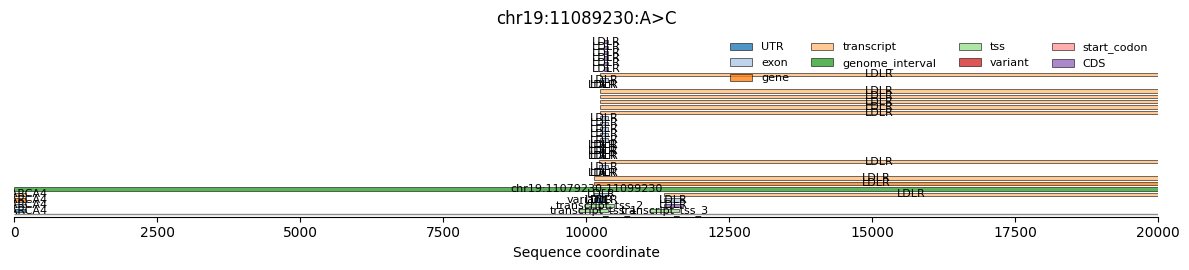

In [93]:
visualizer.plot_result(index=0, kind='sequence')

(<Figure size 1200x800 with 5 Axes>,
 (<Axes: title={'center': 'Variant sequence difference'}>,
  <Axes: title={'center': 'chr19:11089262:C>T'}, xlabel='Sequence coordinate'>,
  <Axes: ylabel='ref ATAC'>,
  <Axes: ylabel='alt ATAC'>,
  <Axes: xlabel='Sequence coordinate', ylabel='delta ATAC'>))

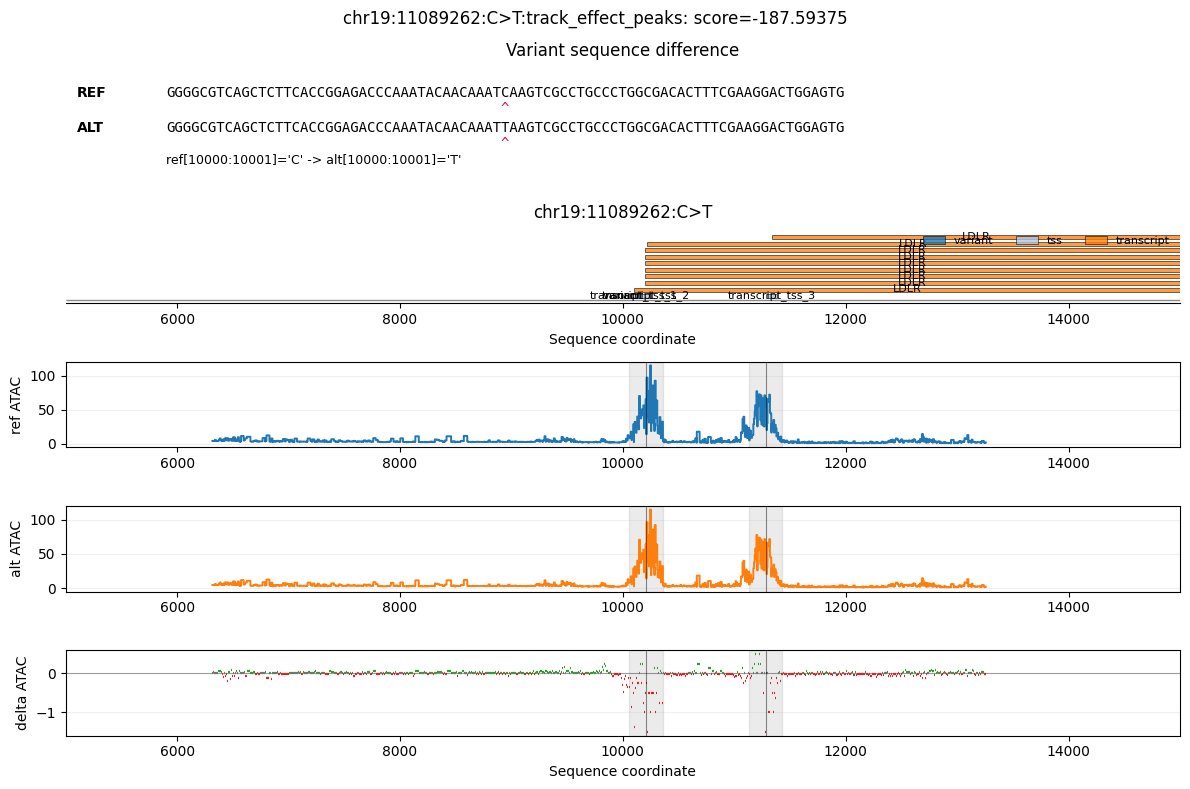

In [32]:
results[100].window(center=10_000, width_bp=10_000).plot_summary(include_annotations=True, annotation_kwargs={'types': ['tss', 'transcript', 'variant']})

(<Figure size 1200x800 with 4 Axes>,
 (<Axes: title={'center': 'Variant sequence difference'}>,
  <Axes: ylabel='ref ATAC'>,
  <Axes: ylabel='alt ATAC'>,
  <Axes: xlabel='Sequence coordinate', ylabel='delta ATAC'>))

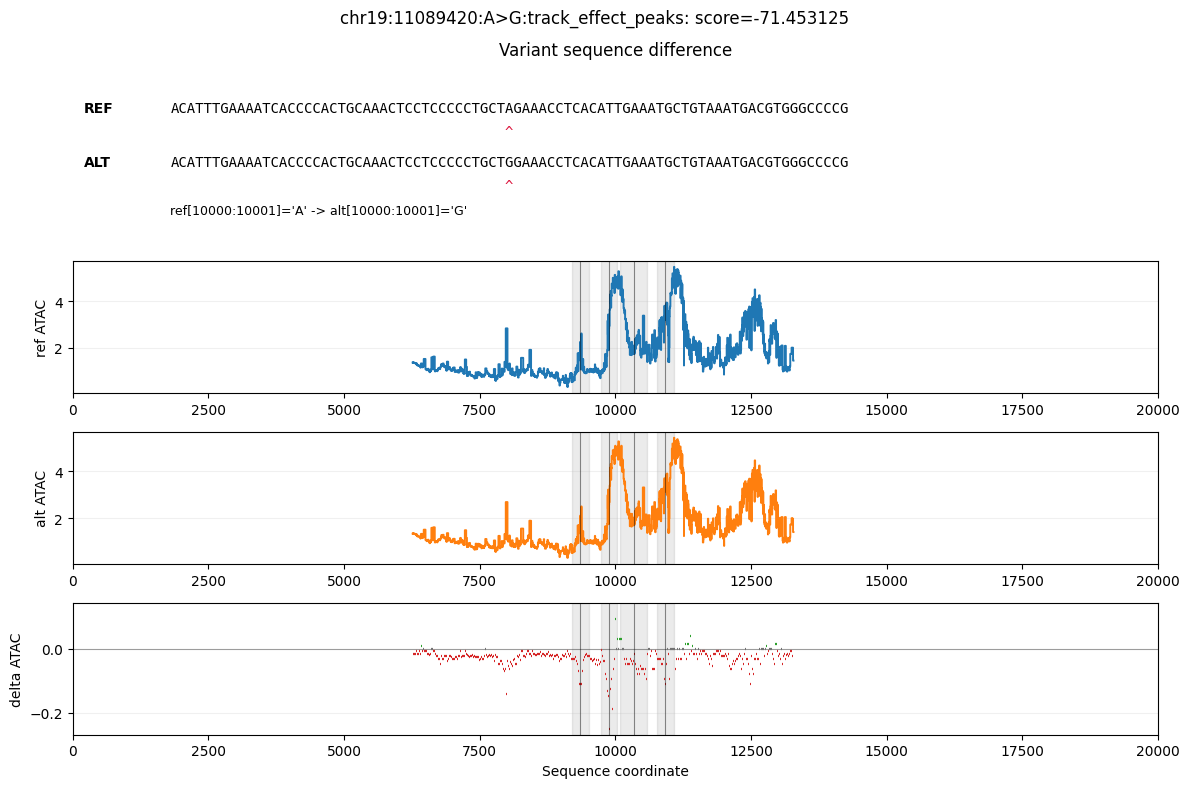

In [31]:
visualizer.plot_result(index=600)

(<Figure size 1600x800 with 2 Axes>,
 array([<Axes: title={'left': 'Measured — Value'}, ylabel='Effect'>,
        <Axes: title={'left': 'Prediction — track_effect_peaks'}, xlabel='Position relative to first observation', ylabel='Effect'>],
       dtype=object))

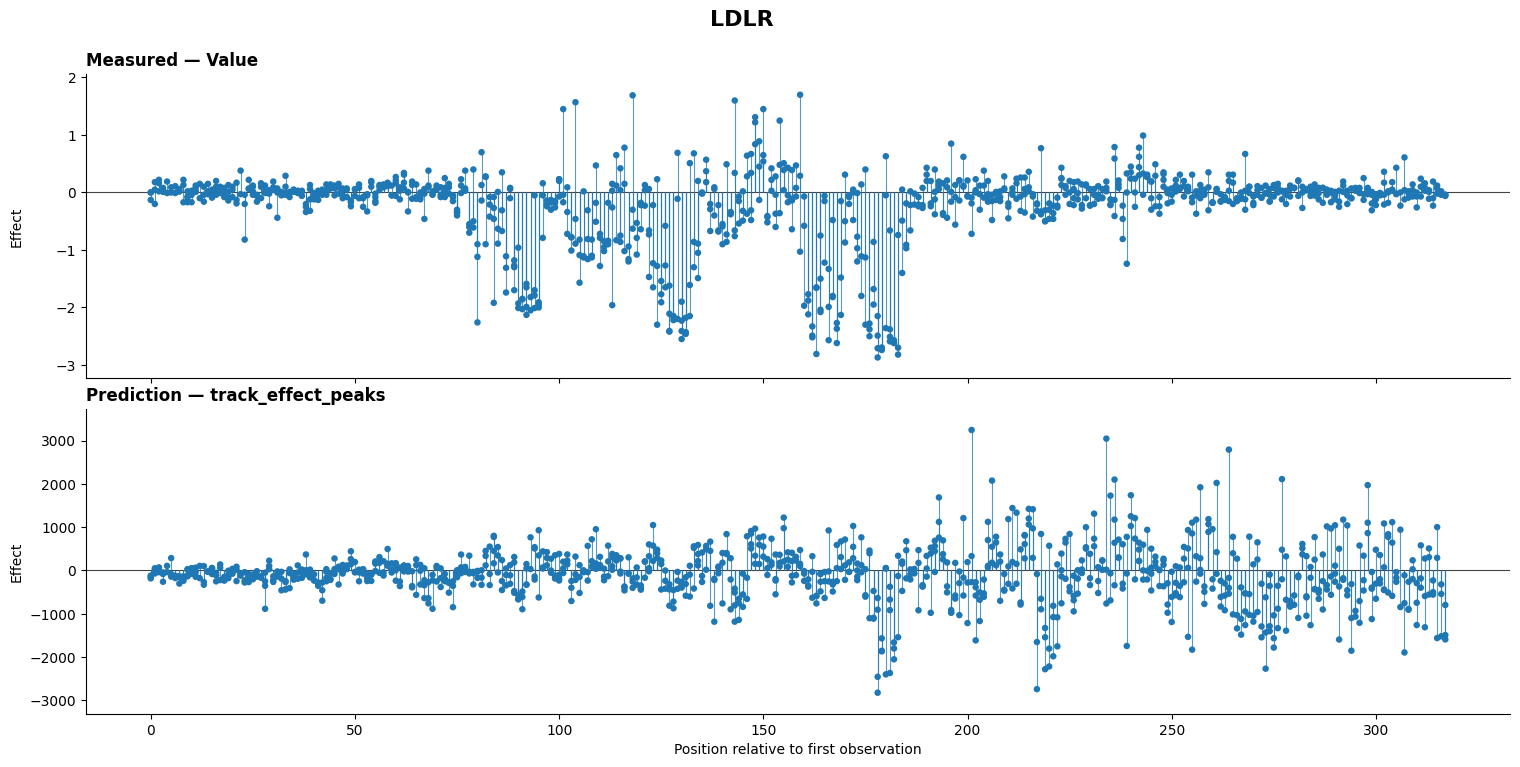

In [35]:
visualizer.plot_variant_effects(element='LDLR', score_name='track_effect_peaks', position_col='Position')

In [36]:
visualizer.correlation_frame()

_strand,_score_name,Element,n,correlation
str,str,str,i64,f64
"""single""","""track_effect_peaks""","""LDLR""",1001,0.192294


In [ ]:
visualizer.plot_variant_effects(element='HBG1', score_name=, position_col='')

_strand,_score_name,Element,n,correlation
str,str,str,i64,f64
"""single""","""chr11:5250012:G>C:track_window""","""HBG1""",1,NaN
"""single""","""chr11:5249980:A>-:track_window""","""HBG1""",1,NaN
"""single""","""chr11:5249943:G>A:track_window""","""HBG1""",1,NaN
"""single""","""chr11:5250069:G>C:track_window""","""HBG1""",1,NaN
"""single""","""chr11:5249949:G>A:track_window""","""HBG1""",1,NaN


In [285]:
var2score = [
    (result.name.removesuffix(':expression_delta'), result.score)
    for result in results
             ]

In [197]:
dataset

Element,Cell_Type,Chromosome,Position,Ref,Alt,Tags,DNA,RNA,Value,P-Value,variant
str,str,str,i64,str,str,i64,i64,i64,f64,f64,str
"""HNF4A""","""HEK293T""","""20""",44355519,"""C""","""A""",542,10233,17645,-0.06,0.03192,"""chr20:44355519:C>A"""
"""HNF4A""","""HEK293T""","""20""",44355519,"""C""","""G""",66,1314,2372,0.01,0.88211,"""chr20:44355519:C>G"""
"""HNF4A""","""HEK293T""","""20""",44355519,"""C""","""T""",2295,42179,75672,0.0,0.86314,"""chr20:44355519:C>T"""
"""HNF4A""","""HEK293T""","""20""",44355520,"""C""","""A""",467,8736,15831,-0.01,0.70191,"""chr20:44355520:C>A"""
"""HNF4A""","""HEK293T""","""20""",44355520,"""C""","""G""",93,1731,3110,0.05,0.51089,"""chr20:44355520:C>G"""
…,…,…,…,…,…,…,…,…,…,…,…
"""HNF4A""","""HEK293T""","""20""",44355802,"""C""","""T""",2058,43837,77309,0.02,0.14742,"""chr20:44355802:C>T"""
"""HNF4A""","""HEK293T""","""20""",44355803,"""C""","""-""",585,11851,20302,-0.02,0.50582,"""chr20:44355803:C>-"""
"""HNF4A""","""HEK293T""","""20""",44355803,"""C""","""A""",50,497,917,-0.19,0.04098,"""chr20:44355803:C>A"""


In [286]:
var2score

[('chr5:1294988:T>-:track_window', -592.65625),
 ('chr5:1294988:T>A:track_window', -556.3828125),
 ('chr5:1294988:T>C:track_window', -474.2578125),
 ('chr5:1294988:T>G:track_window', -440.171875),
 ('chr5:1294989:C>-:track_window', -562.203125),
 ('chr5:1294989:C>A:track_window', -294.3203125),
 ('chr5:1294989:C>T:track_window', -498.1328125),
 ('chr5:1294990:G>-:track_window', -433.921875),
 ('chr5:1294990:G>A:track_window', -385.828125),
 ('chr5:1294990:G>C:track_window', -310.1640625),
 ('chr5:1294990:G>T:track_window', -172.9921875),
 ('chr5:1294991:C>-:track_window', -291.6015625),
 ('chr5:1294991:C>A:track_window', -314.96875),
 ('chr5:1294991:C>G:track_window', -319.9140625),
 ('chr5:1294991:C>T:track_window', -83.46875),
 ('chr5:1294992:G>A:track_window', -191.21875),
 ('chr5:1294992:G>C:track_window', -142.7890625),
 ('chr5:1294992:G>T:track_window', -166.2265625),
 ('chr5:1294993:G>A:track_window', -196.6171875),
 ('chr5:1294993:G>C:track_window', -122.84375),
 ('chr5:1294993

In [287]:
dataset_results = dataset.with_columns(score = pl.Series(name='score', values=[result.score for result in results]))

In [288]:
dataset_results['score'].max()

1020.6875

In [29]:
dataset_results_filtered = dataset_results.filter((pl.col('score') > 0.01) | (pl.col('score') < -0.01))

In [ ]:
while True:
    continue

KeyboardInterrupt: 

In [115]:
results_reverse_complement = interpreter.score_sequence_pairs(
    pairs=reverse_complement_pairs,
    conditions=conditions,
    scorer=all_features_scorer,
    grouping="condition",
    max_records_per_forward=400,
    preprocessing_workers=5, 
    prefetch_batches=4,
    show_progress=True,
)

INFO:gena_expression.models:Starting process preprocessing with 5 worker(s)
INFO:gena_expression.models:Predicting references: 887 row(s), 3 forward batch(es), grouping=condition, preprocessing=process/5, prefetch=4
Predicting references:   0%|          | 0/3 [00:01<?, ?batch/s]
Exception in initializer:
Traceback (most recent call last):
  File "/home/jovyan/miniconda3/envs/api/lib/python3.11/concurrent/futures/process.py", line 240, in _process_worker
    initializer(*initargs)
  File "/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/models.py", line 69, in _process_worker_init
    from transformers import AutoTokenizer
  File "/home/jovyan/miniconda3/envs/api/lib/python3.11/site-packages/transformers/__init__.py", line 27, in <module>
    from . import dependency_versions_check
  File "/home/jovyan/miniconda3/envs/api/lib/python3.11/site-packages/transformers/dependency_versions_check.py", line 16, in <module>
    from .utils.ve

KeyboardInterrupt: 

In [ ]:
while True:
    continue

KeyboardInterrupt: 

In [79]:
import numpy as np
import polars as pl

def compute_element_correlations(
    result: pl.DataFrame,
    *,
    element_col="Element",
    target_col="Value",
    pred_col="alphagenome_score",
    method="pearson",
    min_n=2,
):
    """
    Returns:
        dict[element] = correlation between experimental Value and AlphaGenome score
    """

    if not isinstance(result, pl.DataFrame):
        result = pl.from_pandas(result)

    df = (
        result
        .select(element_col, target_col, pred_col)
        .drop_nulls([element_col, target_col, pred_col])
    )

    correlations = {}

    for key, group in df.partition_by(element_col, as_dict=True).items():
        element = key[0] if isinstance(key, tuple) else key

        x = group[target_col].cast(pl.Float64).to_numpy()
        y = group[pred_col].cast(pl.Float64).to_numpy()

        if len(x) < min_n or np.std(x) == 0 or np.std(y) == 0:
            correlations[element] = np.nan
            continue

        if method == "pearson":
            corr = np.corrcoef(x, y)[0, 1]

        elif method == "spearman":
            x_rank = pl.Series(x).rank("average").to_numpy()
            y_rank = pl.Series(y).rank("average").to_numpy()
            corr = np.corrcoef(x_rank, y_rank)[0, 1]

        else:
            raise ValueError("method must be 'pearson' or 'spearman'")

        correlations[element] = float(corr)

    return correlations

In [ ]:
corrs = compute_feature_correlations(results = results, results_reverse=results_reverse_complement, dataset=dataset, method='pearson')

In [289]:
corr_dict_500 = compute_element_correlations(result=dataset_results, pred_col='score', method='pearson')

In [290]:
corr_dict_500

{'TERT-GBM': 0.3672392450971049}

In [84]:
result = pl.read_csv('/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/results/expression_model_v1-1.tsv', separator='\t', infer_schema_length=10000)

In [89]:
compute_element_correlations(result=result, pred_col='track_window_501bp_variant_tss_oriented')

{'BCL11A': 0.10951872597704367,
 'F9': 0.24334452670016907,
 'FOXE1': 0.035107054530290595,
 'GP1BA': 0.4613470226738165,
 'HBB': 0.48086959924163725,
 'HBG1': 0.3471080702799205,
 'HNF4A': -0.0710896897251904,
 'IRF4': 0.32010722249126317,
 'IRF6': 0.18039673117080526,
 'LDLR': 0.20454606439162537,
 'LDLR.2': 0.22812681357363065,
 'MSMB': 0.15314199535737907,
 'MYCrs11986220': 0.02326633179209512,
 'MYCrs6983267': 0.1984572699649111,
 'PKLR-24h': 0.4720115562828011,
 'PKLR-48h': 0.5215593612427297,
 'RET': 0.011938512681564945,
 'SORT1': 0.2377580467499731,
 'SORT1-flip': 0.2553191932770038,
 'SORT1.2': 0.18489227201834535,
 'TCF7L2': 0.12371091289125921,
 'TERT-GAa': 0.3169040520325389,
 'TERT-GBM': 0.3043044800540821,
 'TERT-GSc': 0.2895614200244879,
 'TERT-HEK': 0.47767484902486085,
 'UC88': 0.11402113119638732,
 'ZFAND3': 0.12208857513653076,
 'ZRSh-13': 0.09878531353304797,
 'ZRSh-13h2': 0.10952238708546248}

In [90]:
compute_element_correlations(result=result, pred_col='track_window_501bp_variant_tss_oriented')

{'BCL11A': 0.10951872597704367,
 'F9': 0.24334452670016907,
 'FOXE1': 0.035107054530290595,
 'GP1BA': 0.4613470226738165,
 'HBB': 0.48086959924163725,
 'HBG1': 0.3471080702799205,
 'HNF4A': -0.0710896897251904,
 'IRF4': 0.32010722249126317,
 'IRF6': 0.18039673117080526,
 'LDLR': 0.20454606439162537,
 'LDLR.2': 0.22812681357363065,
 'MSMB': 0.15314199535737907,
 'MYCrs11986220': 0.02326633179209512,
 'MYCrs6983267': 0.1984572699649111,
 'PKLR-24h': 0.4720115562828011,
 'PKLR-48h': 0.5215593612427297,
 'RET': 0.011938512681564945,
 'SORT1': 0.2377580467499731,
 'SORT1-flip': 0.2553191932770038,
 'SORT1.2': 0.18489227201834535,
 'TCF7L2': 0.12371091289125921,
 'TERT-GAa': 0.3169040520325389,
 'TERT-GBM': 0.3043044800540821,
 'TERT-GSc': 0.2895614200244879,
 'TERT-HEK': 0.47767484902486085,
 'UC88': 0.11402113119638732,
 'ZFAND3': 0.12208857513653076,
 'ZRSh-13': 0.09878531353304797,
 'ZRSh-13h2': 0.10952238708546248}

In [91]:
compute_element_correlations(result=result, pred_col='track_window_201bp_variant_tss_oriented')

{'BCL11A': 0.11051238512351716,
 'F9': 0.22674687713185257,
 'FOXE1': 0.037352171549376666,
 'GP1BA': 0.4371528717439773,
 'HBB': 0.49579430973344524,
 'HBG1': 0.4270059236792042,
 'HNF4A': -0.07455092503135263,
 'IRF4': 0.31723582884806345,
 'IRF6': 0.18860262219651452,
 'LDLR': 0.15866468303277334,
 'LDLR.2': 0.1738285247675306,
 'MSMB': 0.1907806794161212,
 'MYCrs11986220': 0.034577983699442726,
 'MYCrs6983267': 0.21852393741254997,
 'PKLR-24h': 0.4912139489246031,
 'PKLR-48h': 0.5435038736965954,
 'RET': 0.04778966960685032,
 'SORT1': 0.2452274642576105,
 'SORT1-flip': 0.2627211301807453,
 'SORT1.2': 0.19007704057024635,
 'TCF7L2': 0.1235030195609316,
 'TERT-GAa': 0.36572957533696643,
 'TERT-GBM': 0.360161917453364,
 'TERT-GSc': 0.3423422665417901,
 'TERT-HEK': 0.49256196337517083,
 'UC88': 0.12215214891996556,
 'ZFAND3': 0.18432628607594223,
 'ZRSh-13': 0.09262466839955444,
 'ZRSh-13h2': 0.10482300785368144}

In [100]:
ENHANCER_ELEMENTS = {
    "BCL11A",
    "IRF4",
    "IRF6",
    "MYCrs6983267",
    "MYCrs11986220",
    "RET",
    "SORT1",
    "SORT1-flip",
    "SORT1.2",
    "TCF7L2",
    "UC88",
    "ZFAND3",
    "ZRSh-13",
    "ZRSh-13h2",
}
PROMOTER_ELEMENTS = {
    "F9",
    "FOXE1",
    "GP1BA",
    "HBB",
    "HBG1",
    "HNF4A",
    "LDLR",
    "LDLR.2",
    "MSMB",
    "PKLR-24h",
    "PKLR-48h",
    "TERT-GAa",
    "TERT-GBM",
    "TERT-GSc",
    "TERT-HEK",
}

In [113]:
scorers = [
    #'track_window_501bp_variant_tss_oriented',
    #'track_window_201bp_variant_tss_oriented',
    #'track_window_101bp_variant_tss_oriented',
    #'track_window_501bp_tss_tss_oriented',
    #'track_window_201bp_tss_tss_oriented',
    #'track_window_101bp_tss_tss_oriented'
    'expr_tss_oriented'
]

In [114]:
scorer2results = {scorer:compute_element_correlations(result=result, pred_col=scorer) for scorer in scorers}

In [115]:
scorer2results_promoters = {k : {K:V for K, V in v.items() if K in PROMOTER_ELEMENTS} for k, v in scorer2results.items()}
scorer2results_enhancers = {k : {K:V for K, V in v.items() if K in ENHANCER_ELEMENTS} for k, v in scorer2results.items()}

In [116]:
scorer2results_promoters

{'expr_tss_oriented': {'F9': 0.22803481889224858,
  'FOXE1': 0.016395550166622908,
  'GP1BA': 0.31952114908252965,
  'HBB': 0.2731853604439778,
  'HBG1': 0.11524891461813559,
  'HNF4A': -0.08084245327467068,
  'LDLR': 0.08330192047090339,
  'LDLR.2': 0.10098446801995785,
  'MSMB': -0.0630021795364252,
  'PKLR-24h': 0.5255802048058063,
  'PKLR-48h': 0.5789389475092811,
  'TERT-GAa': 0.4240911277160606,
  'TERT-GBM': 0.49073573162632034,
  'TERT-GSc': 0.46755297677660695,
  'TERT-HEK': 0.5105722061393858}}

(<Figure size 2155x280 with 1 Axes>,
 <Axes: title={'center': 'Correlations (15 elements)'}>)

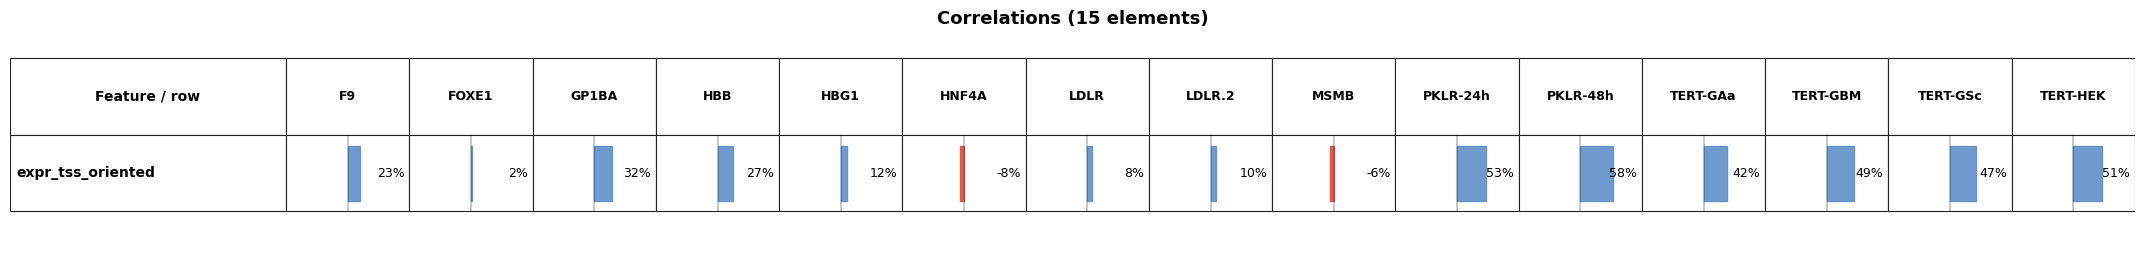

In [117]:
plot_feature_correlation_table(correlations=scorer2results_promoters)

In [95]:
scorer2results

{'track_window_501bp_variant_tss_oriented': {'BCL11A': 0.10951872597704367,
  'F9': 0.24334452670016907,
  'FOXE1': 0.035107054530290595,
  'GP1BA': 0.4613470226738165,
  'HBB': 0.48086959924163725,
  'HBG1': 0.3471080702799205,
  'HNF4A': -0.0710896897251904,
  'IRF4': 0.32010722249126317,
  'IRF6': 0.18039673117080526,
  'LDLR': 0.20454606439162537,
  'LDLR.2': 0.22812681357363065,
  'MSMB': 0.15314199535737907,
  'MYCrs11986220': 0.02326633179209512,
  'MYCrs6983267': 0.1984572699649111,
  'PKLR-24h': 0.4720115562828011,
  'PKLR-48h': 0.5215593612427297,
  'RET': 0.011938512681564945,
  'SORT1': 0.2377580467499731,
  'SORT1-flip': 0.2553191932770038,
  'SORT1.2': 0.18489227201834535,
  'TCF7L2': 0.12371091289125921,
  'TERT-GAa': 0.3169040520325389,
  'TERT-GBM': 0.3043044800540821,
  'TERT-GSc': 0.2895614200244879,
  'TERT-HEK': 0.47767484902486085,
  'UC88': 0.11402113119638732,
  'ZFAND3': 0.12208857513653076,
  'ZRSh-13': 0.09878531353304797,
  'ZRSh-13h2': 0.10952238708546248},

In [87]:
compute_element_correlations(result=result, pred_col='track_window_201bp_tss_tss_oriented')

{'BCL11A': 0.08043868315051315,
 'F9': 0.19930356378494307,
 'FOXE1': 0.025168604253826384,
 'GP1BA': 0.3356221116879554,
 'HBB': 0.47482999220839295,
 'HBG1': 0.25236218915082315,
 'HNF4A': -0.07326746374569043,
 'IRF4': nan,
 'LDLR': 0.16650405168855337,
 'LDLR.2': 0.192220010699556,
 'MSMB': 0.15093666803381847,
 'MYCrs6983267': -0.02512685348844373,
 'PKLR-24h': 0.4632340854497237,
 'PKLR-48h': 0.5112998061356334,
 'SORT1': nan,
 'SORT1-flip': nan,
 'SORT1.2': nan,
 'TERT-GAa': 0.15803423629406374,
 'TERT-GBM': 0.11387389223361259,
 'TERT-GSc': 0.11139331548402151,
 'TERT-HEK': 0.3860976301031929,
 'ZRSh-13': nan,
 'ZRSh-13h2': nan}

In [ ]:
corr_dict_500

In [ ]:
corr_dict = compute_feature_correlations(results=results, dataset=dataset)

In [ ]:
corr_dict_500

{'BCL11A': {'left_genome_flank': 0.033098957404709174,
  'source#1': 0.05434720797657406,
  'ColE1-derived plasmid replication origin#1': 0.05312021053700802,
  'beta-lactamase': 0.05381855948811538,
  'synthetic; transcriptional pause site': 0.0234965213385634,
  'source#2': 0.08915937763628075,
  'Hind III restriction site was changed to EcoRI restriction site; Multiple cloning site region': 0.09166859268549546,
  'minimal TATA-box promoter with low basal activity': 0.09658630144486241,
  'firefly luciferase': 0.044098673506629577,
  'sequence was changed from the original sequence; fixed GC stretch': 0.01841264025625105,
  'SV40 polyadenylation signal; SV40 late poly(A) region': 0.02116177069259689,
  'ColE1-derived plasmid replication origin#2': 0.03458814788649753,
  'left_mcs_scar': 0.027849887834479854,
  'mpra_fragment': 0.08985112949074303,
  'variant': 0.0007835999716174502,
  'mpra_insert': 0.08985112949074303,
  'right_mcs_scar': 0.0940107578351076,
  'reporter_tss': 0.0493

In [ ]:
import json

In [ ]:
corr_dict

{'BCL11A': {'left_genome_flank': 0.033098957404709174,
  'source#1': 0.05434720797657406,
  'ColE1-derived plasmid replication origin#1': 0.05312021053700802,
  'beta-lactamase': 0.05381855948811538,
  'synthetic; transcriptional pause site': 0.0234965213385634,
  'source#2': 0.08915937763628075,
  'Hind III restriction site was changed to EcoRI restriction site; Multiple cloning site region': 0.09166859268549546,
  'minimal TATA-box promoter with low basal activity': 0.09658630144486241,
  'firefly luciferase': 0.044098673506629577,
  'sequence was changed from the original sequence; fixed GC stretch': 0.01841264025625105,
  'SV40 polyadenylation signal; SV40 late poly(A) region': 0.02116177069259689,
  'ColE1-derived plasmid replication origin#2': 0.03458814788649753,
  'left_mcs_scar': 0.027849887834479854,
  'mpra_fragment': 0.08985112949074303,
  'variant': 0.0007835999716174502,
  'mpra_insert': 0.08985112949074303,
  'right_mcs_scar': 0.0940107578351076,
  'reporter_tss': 0.0493

(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': '19:55115008'}, xlabel='Sequence coordinate'>)

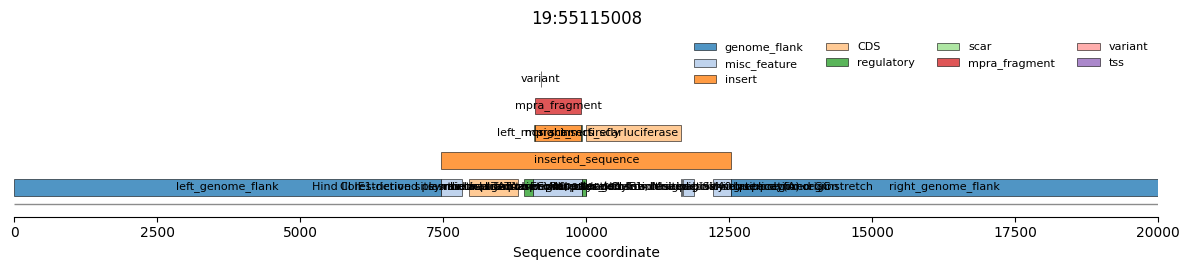

In [ ]:
results[0].input_ref.plot_annotations()

In [ ]:
with open('../data/corr_dict.json', 'w') as file:
    json.dump(corr_dict, file, indent=6)

(<Figure size 2280x461 with 1 Axes>, <Axes: title={'center': 'Promoters'}>)

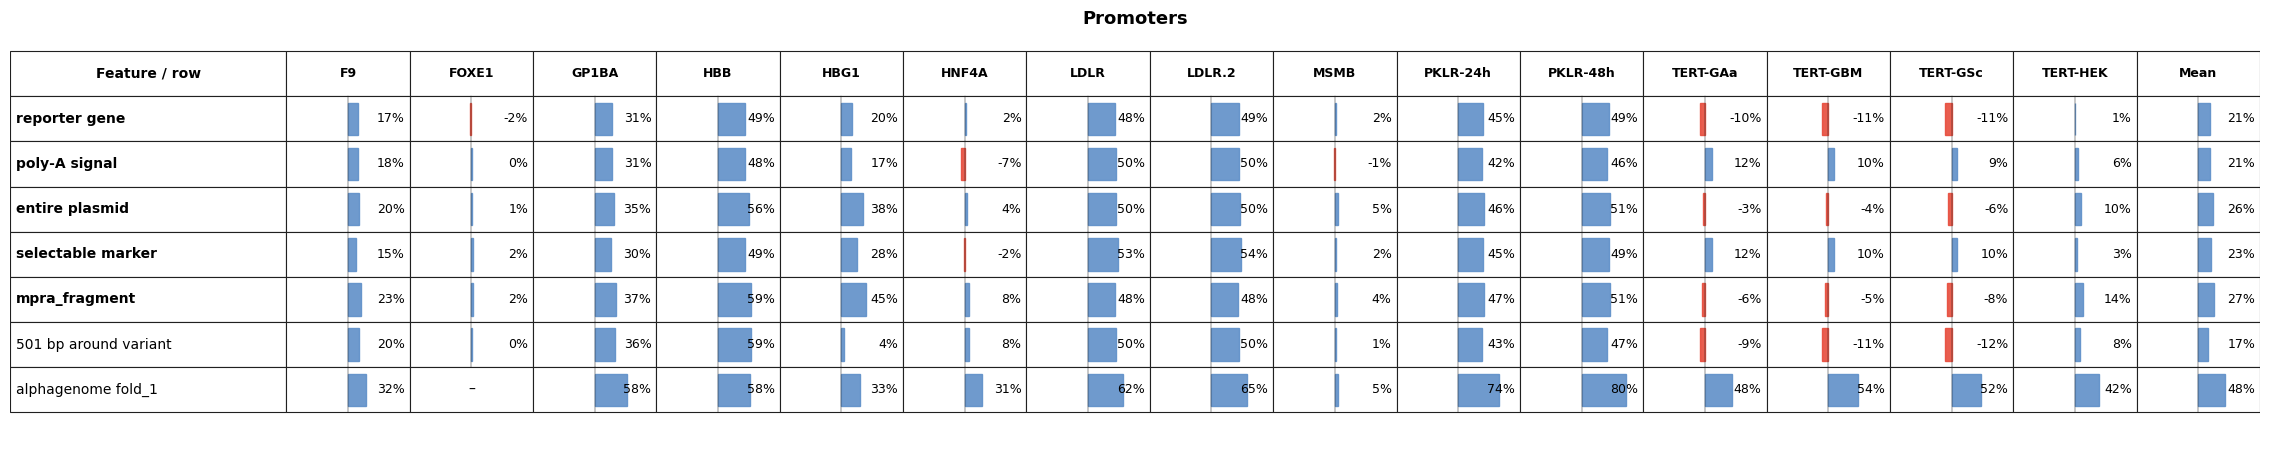

In [ ]:
plot_feature_correlation_table(correlations={k:v for k, v in corrs.items() if k in PROMOTER_ELEMENTS}, features_to_plot={'mpra_fragment', 'selectable marker', 'reporter gene', 'entire plasmid', 'poly-A signal'}, 
                                                    feature_rename={'beta-lactamase': 'selectable marker',
                                                                                                        'similar to beta-lactamase; confers resistance to ampicillin, carbenicillin, and related antibiotics': 'selectable marker',
                                                                                                        'firefly luciferase': 'reporter gene',
                                                                                                        'similar to firefly luciferase; synthetic luc2 version of the luciferase gene': 'reporter gene',
                                                                                                        'inserted_sequence': 'entire plasmid',
                                                                                                        'SV40 late poly(A) region': 'poly-A signal',
                                                                                                        'SV40 late poly (A) region': 'poly-A signal',
                                                                                                        'SV40 late polyA': 'poly-A signal',
                                                                                                        'SV40 polyadenylation signal; SV40 late poly(A) region': 'poly-A signal',
                                                                                                        'minimal TATA-box promoter with low basal activity': 'minimal promoter'
                                                                                                        },
                                                    title='Promoters',
                                                    additional_rows={
                                                        '501 bp around variant': {'BCL11A': 0.12625925117905426,
                                                                                    'F9': 0.20487283828633102,
                                                                                    'FOXE1': 0.004947508508490845,
                                                                                    'GP1BA': 0.3563257347219234,
                                                                                    'HBB': 0.5927781312088172,
                                                                                    'HBG1': 0.039394474429226146,
                                                                                    'HNF4A': 0.07520973994398414,
                                                                                    'IRF4': 0.39899298193043947,
                                                                                    'IRF6': 0.19624047444254955,
                                                                                    'LDLR': 0.49918983132733225,
                                                                                    'LDLR.2': 0.4999637636792505,
                                                                                    'MSMB': 0.013194963731142977,
                                                                                    'MYCrs11986220': 0.02559018642231635,
                                                                                    'MYCrs6983267': 0.08771609119554025,
                                                                                    'PKLR-24h': 0.42577426792354783,
                                                                                    'PKLR-48h': 0.46530672387660466,
                                                                                    'RET': 0.07925590358801235,
                                                                                    'SORT1': 0.053286344544520366,
                                                                                    'SORT1-flip': -0.00032808650562150777,
                                                                                    'SORT1.2': 0.04625973464266156,
                                                                                    'TCF7L2': -0.06477833505138726,
                                                                                    'TERT-GAa': -0.09467608032825657,
                                                                                    'TERT-GBM': -0.10742022719667728,
                                                                                    'TERT-GSc': -0.11869370779649803,
                                                                                    'TERT-HEK': 0.08235562016635282,
                                                                                    'UC88': 0.22359123479260634,
                                                                                    'ZFAND3': 0.10498439667946516,
                                                                                    'ZRSh-13': 0.10646926841551994,
                                                                                    'ZRSh-13h2': 0.15910545025108985},
                                                        'alphagenome fold_1': {'F9': 0.31728714205494446,
                                                                                'GP1BA': 0.5816504189651528,
                                                                                'HBB': 0.58134609703809,
                                                                                'HBG1': 0.32945875292047283,
                                                                                'HNF4A': 0.30658287735851053,
                                                                                'IRF4': 0.7276665259829245,
                                                                                'IRF6': 0.688767539365959,
                                                                                'LDLR': 0.6165281808481928,
                                                                                'LDLR.2': 0.6458270371565045,
                                                                                'MSMB': 0.05441078333694314,
                                                                                'MYCrs11986220': -0.01073324033826045,
                                                                                'MYCrs6983267': 0.3874566606541967,
                                                                                'PKLR-24h': 0.7390854516789516,
                                                                                'PKLR-48h': 0.8039249678391265,
                                                                                'SORT1': 0.7098379585780255,
                                                                                'SORT1-flip': 0.6898911964035332,
                                                                                'SORT1.2': 0.6784959353065811,
                                                                                'TERT-GAa': 0.4827466178814113,
                                                                                'TERT-GBM': 0.5378001158262097,
                                                                                'TERT-GSc': 0.5244270073283473,
                                                                                'TERT-HEK': 0.42458970739680746,
                                                                                'ZFAND3': 0.37890938467251206},
                                                    },
                                                    last_column_name="Mean",
                                                    last_column_score=lambda el2corr: mean(el2corr),
                                                    )

(<Figure size 1780x513 with 1 Axes>, <Axes: title={'center': 'Enhancers'}>)

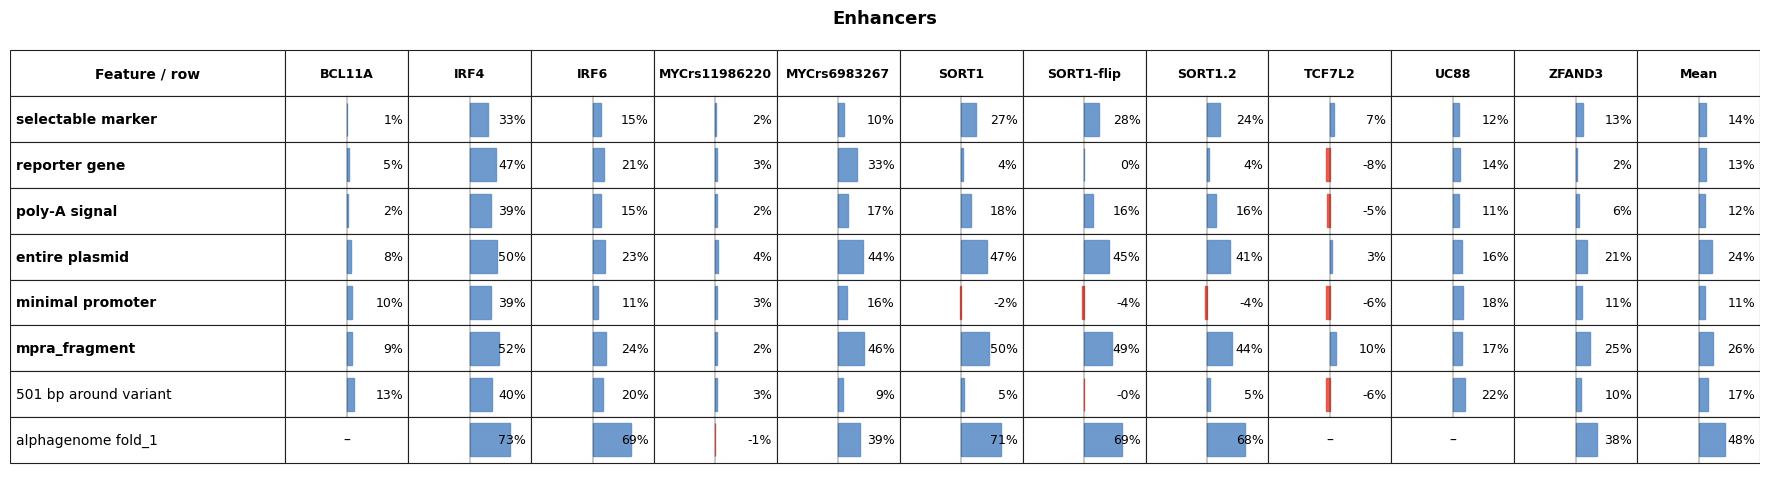

In [ ]:
plot_feature_correlation_table(correlations={k:v for k, v in corrs.items() if k in ENHANCER_ELEMENTS}, features_to_plot={'mpra_fragment', 'selectable marker', 'reporter gene', 'entire plasmid', 'poly-A signal','minimal promoter'}, 
                                                    feature_rename={'beta-lactamase': 'selectable marker',
                                                                    'similar to beta-lactamase; confers resistance to ampicillin, carbenicillin, and related antibiotics': 'selectable marker',
                                                                    'firefly luciferase': 'reporter gene',
                                                                    'similar to firefly luciferase; synthetic luc2 version of the luciferase gene': 'reporter gene',
                                                                    'inserted_sequence': 'entire plasmid',
                                                                    'SV40 late poly(A) region': 'poly-A signal',
                                                                    'SV40 late poly (A) region': 'poly-A signal',
                                                                    'SV40 late polyA': 'poly-A signal',
                                                                    'SV40 polyadenylation signal; SV40 late poly(A) region': 'poly-A signal',
                                                                    'minimal TATA-box promoter with low basal activity': 'minimal promoter'
                                                                    },
                                                    title='Enhancers',
                                                    additional_rows={
                                                        '501 bp around variant': {'BCL11A': 0.12625925117905426,
                                                                                    'F9': 0.20487283828633102,
                                                                                    'FOXE1': 0.004947508508490845,
                                                                                    'GP1BA': 0.3563257347219234,
                                                                                    'HBB': 0.5927781312088172,
                                                                                    'HBG1': 0.039394474429226146,
                                                                                    'HNF4A': 0.07520973994398414,
                                                                                    'IRF4': 0.39899298193043947,
                                                                                    'IRF6': 0.19624047444254955,
                                                                                    'LDLR': 0.49918983132733225,
                                                                                    'LDLR.2': 0.4999637636792505,
                                                                                    'MSMB': 0.013194963731142977,
                                                                                    'MYCrs11986220': 0.02559018642231635,
                                                                                    'MYCrs6983267': 0.08771609119554025,
                                                                                    'PKLR-24h': 0.42577426792354783,
                                                                                    'PKLR-48h': 0.46530672387660466,
                                                                                    'RET': 0.07925590358801235,
                                                                                    'SORT1': 0.053286344544520366,
                                                                                    'SORT1-flip': -0.00032808650562150777,
                                                                                    'SORT1.2': 0.04625973464266156,
                                                                                    'TCF7L2': -0.06477833505138726,
                                                                                    'TERT-GAa': -0.09467608032825657,
                                                                                    'TERT-GBM': -0.10742022719667728,
                                                                                    'TERT-GSc': -0.11869370779649803,
                                                                                    'TERT-HEK': 0.08235562016635282,
                                                                                    'UC88': 0.22359123479260634,
                                                                                    'ZFAND3': 0.10498439667946516,
                                                                                    'ZRSh-13': 0.10646926841551994,
                                                                                    'ZRSh-13h2': 0.15910545025108985},
                                                        'alphagenome fold_1': {'F9': 0.31728714205494446,
                                                                                'GP1BA': 0.5816504189651528,
                                                                                'HBB': 0.58134609703809,
                                                                                'HBG1': 0.32945875292047283,
                                                                                'HNF4A': 0.30658287735851053,
                                                                                'IRF4': 0.7276665259829245,
                                                                                'IRF6': 0.688767539365959,
                                                                                'LDLR': 0.6165281808481928,
                                                                                'LDLR.2': 0.6458270371565045,
                                                                                'MSMB': 0.05441078333694314,
                                                                                'MYCrs11986220': -0.01073324033826045,
                                                                                'MYCrs6983267': 0.3874566606541967,
                                                                                'PKLR-24h': 0.7390854516789516,
                                                                                'PKLR-48h': 0.8039249678391265,
                                                                                'SORT1': 0.7098379585780255,
                                                                                'SORT1-flip': 0.6898911964035332,
                                                                                'SORT1.2': 0.6784959353065811,
                                                                                'TERT-GAa': 0.4827466178814113,
                                                                                'TERT-GBM': 0.5378001158262097,
                                                                                'TERT-GSc': 0.5244270073283473,
                                                                                'TERT-HEK': 0.42458970739680746,
                                                                                'ZFAND3': 0.37890938467251206}
                                                    },
                                                    last_column_name="Mean",
                                                    last_column_score=lambda el2corr: mean(el2corr),
                                                    )

In [ ]:
compute_element_correlations(
    result = dataset.with_columns(scores = pl.Series(name='scores', values = scores)),
    pred_col='scores'
)

{'BCL11A': 0.12625925117905426,
 'F9': 0.20487283828633102,
 'FOXE1': 0.004947508508490845,
 'GP1BA': 0.3563257347219234,
 'HBB': 0.5927781312088172,
 'HBG1': 0.039394474429226146,
 'HNF4A': 0.07520973994398414,
 'IRF4': 0.39899298193043947,
 'IRF6': 0.19624047444254955,
 'LDLR': 0.49918983132733225,
 'LDLR.2': 0.4999637636792505,
 'MSMB': 0.013194963731142977,
 'MYCrs11986220': 0.02559018642231635,
 'MYCrs6983267': 0.08771609119554025,
 'PKLR-24h': 0.42577426792354783,
 'PKLR-48h': 0.46530672387660466,
 'RET': 0.07925590358801235,
 'SORT1': 0.053286344544520366,
 'SORT1-flip': -0.00032808650562150777,
 'SORT1.2': 0.04625973464266156,
 'TCF7L2': -0.06477833505138726,
 'TERT-GAa': -0.09467608032825657,
 'TERT-GBM': -0.10742022719667728,
 'TERT-GSc': -0.11869370779649803,
 'TERT-HEK': 0.08235562016635282,
 'UC88': 0.22359123479260634,
 'ZFAND3': 0.10498439667946516,
 'ZRSh-13': 0.10646926841551994,
 'ZRSh-13h2': 0.15910545025108985}

In [ ]:
dataset.with_columns(scores = pl.Series(name='scores', values = scores)).select('Value', 'scores').corr()

Value,scores
f64,f64
1.0,0.278785
0.278785,1.0


In [154]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def plot_correlation_json(
    json_path,
    output_path=None,
    *,
    title=None,
    figsize=None,
):
    """Plot forward, reverse, and mean correlations for every element."""
    json_path = Path(json_path)

    with json_path.open("r", encoding="utf-8") as file:
        correlations = json.load(file)

    elements = list(correlations)
    strands = ("forward", "reverse", "mean")
    colors = ("#4C78A8", "#F58518", "#54A24B")

    x = np.arange(len(elements))
    bar_width = 0.25

    if figsize is None:
        figsize = (max(12, len(elements) * 0.7), 6)

    fig, ax = plt.subplots(figsize=figsize)

    for index, (strand, color) in enumerate(zip(strands, colors)):
        values = [
            np.nan
            if correlations[element].get(strand) is None
            else float(correlations[element][strand])
            for element in elements
        ]

        ax.bar(
            x + (index - 1) * bar_width,
            values,
            width=bar_width,
            label=strand.capitalize(),
            color=color,
        )

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(elements, rotation=45, ha="right")
    ax.set_ylabel("Pearson correlation")
    ax.set_ylim(-0.25, 0.7)
    ax.set_title(title or json_path.stem.replace("_", " ").title())
    ax.legend()
    ax.grid(axis="y", alpha=0.2)

    fig.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=200, bbox_inches="tight")

    return fig, ax

(<Figure size 2030x600 with 1 Axes>,
 <Axes: title={'center': 'New checkpoint, expression delta scorer'}, ylabel='Pearson correlation'>)

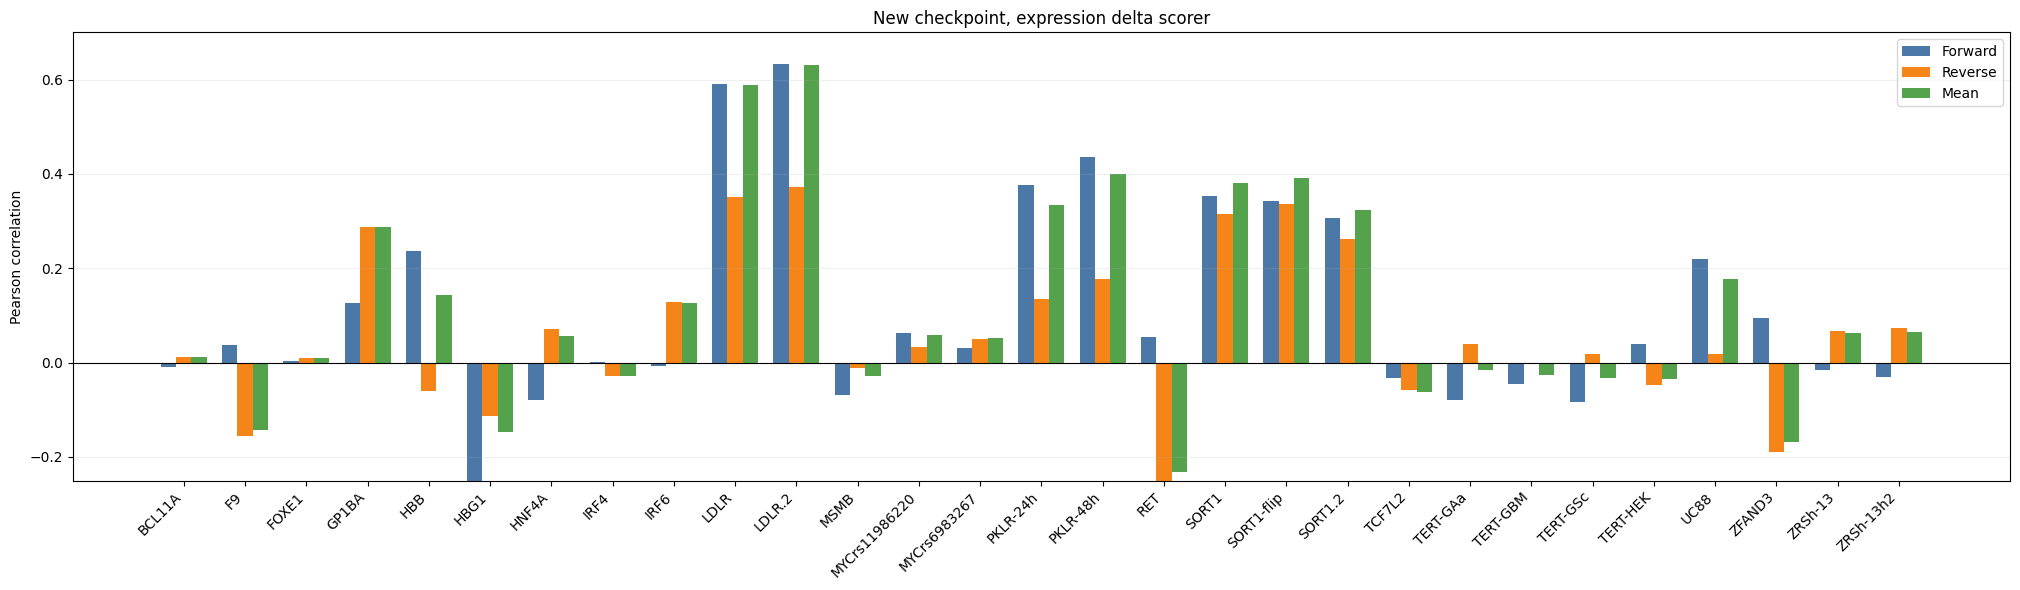

In [155]:
plot_correlation_json('/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/results/forward_reverse_variant_api/expression_correlations.json', title='New checkpoint, expression delta scorer')

(<Figure size 2030x600 with 1 Axes>,
 <Axes: title={'center': 'New checkpoint, expression delta scorer'}, ylabel='Pearson correlation'>)

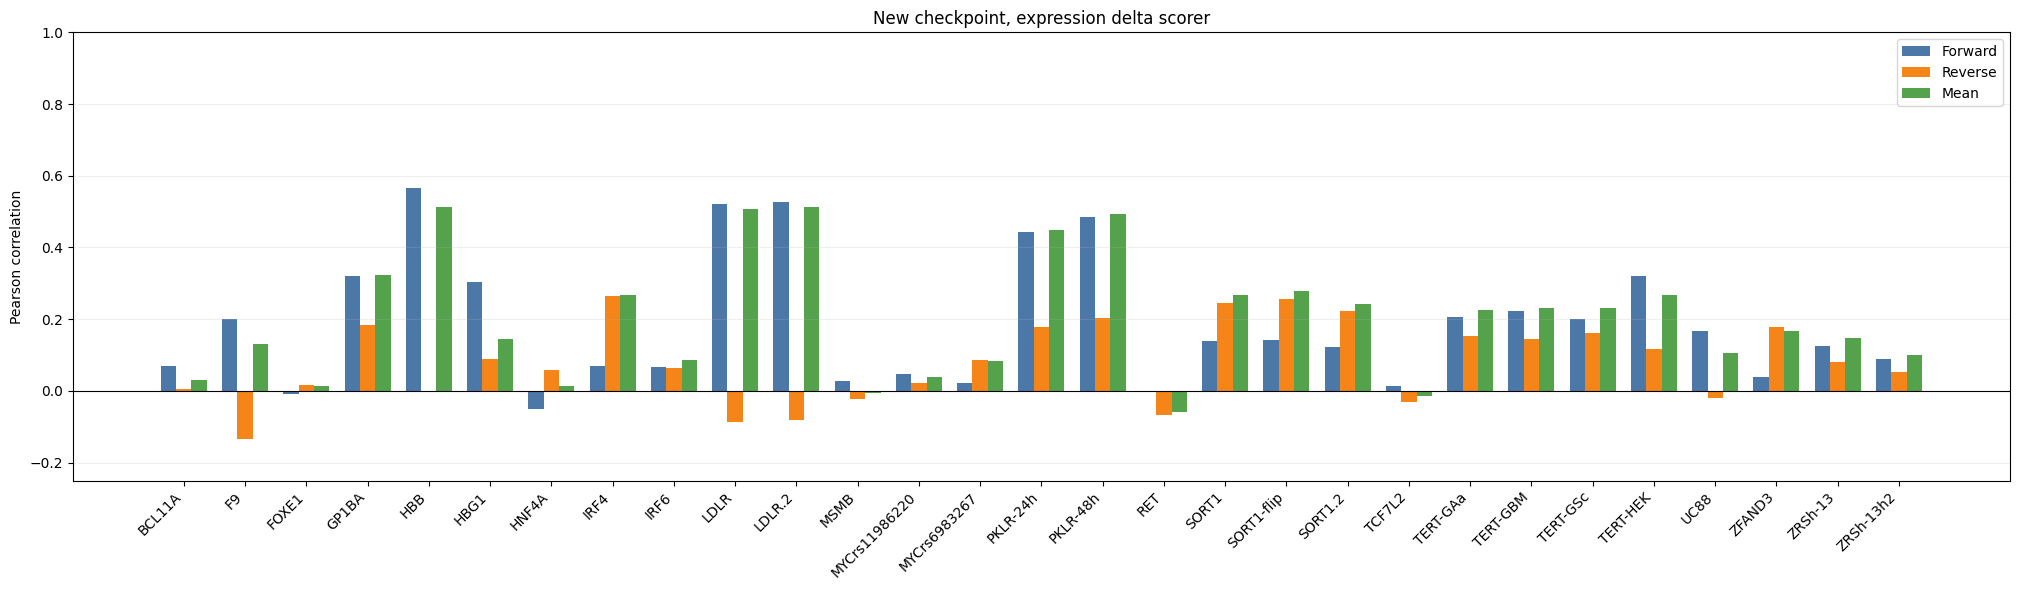

In [ ]:
plot_correlation_json('/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/results/new_checkpoint_results/expression_correlations.json', title='New checkpoint, expression delta scorer')

(<Figure size 2030x600 with 1 Axes>,
 <Axes: title={'center': 'New checkpoint, ATAC-seq sum over mpra fragment'}, ylabel='Pearson correlation'>)

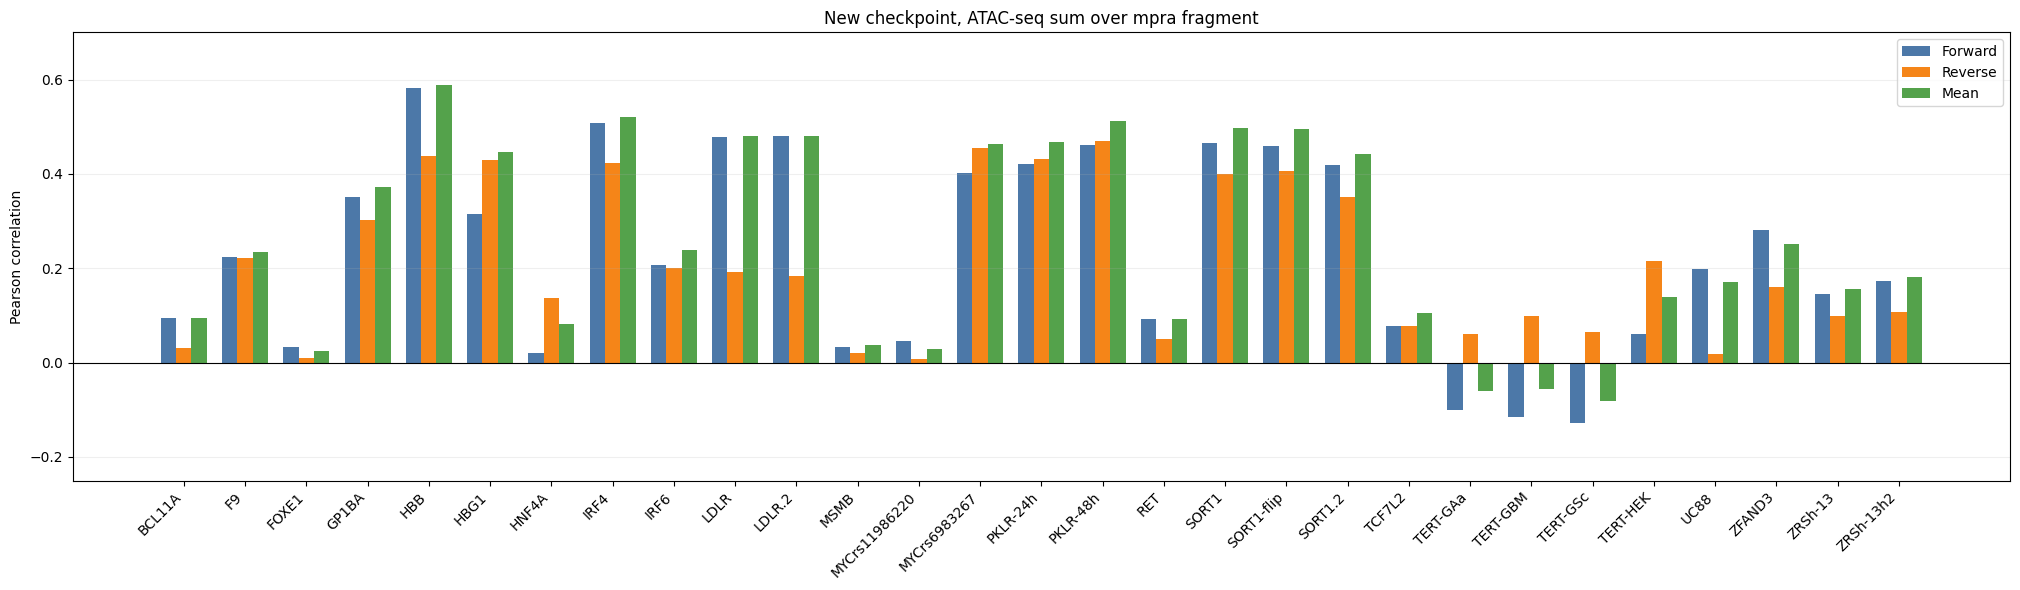

In [ ]:
plot_correlation_json('/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/results/new_checkpoint_results/track_feature_correlations.json', title='New checkpoint, ATAC-seq sum over mpra fragment')

(<Figure size 2030x600 with 1 Axes>,
 <Axes: title={'center': 'Old checkpoint, ATAC-seq sum over mpra fragment'}, ylabel='Pearson correlation'>)

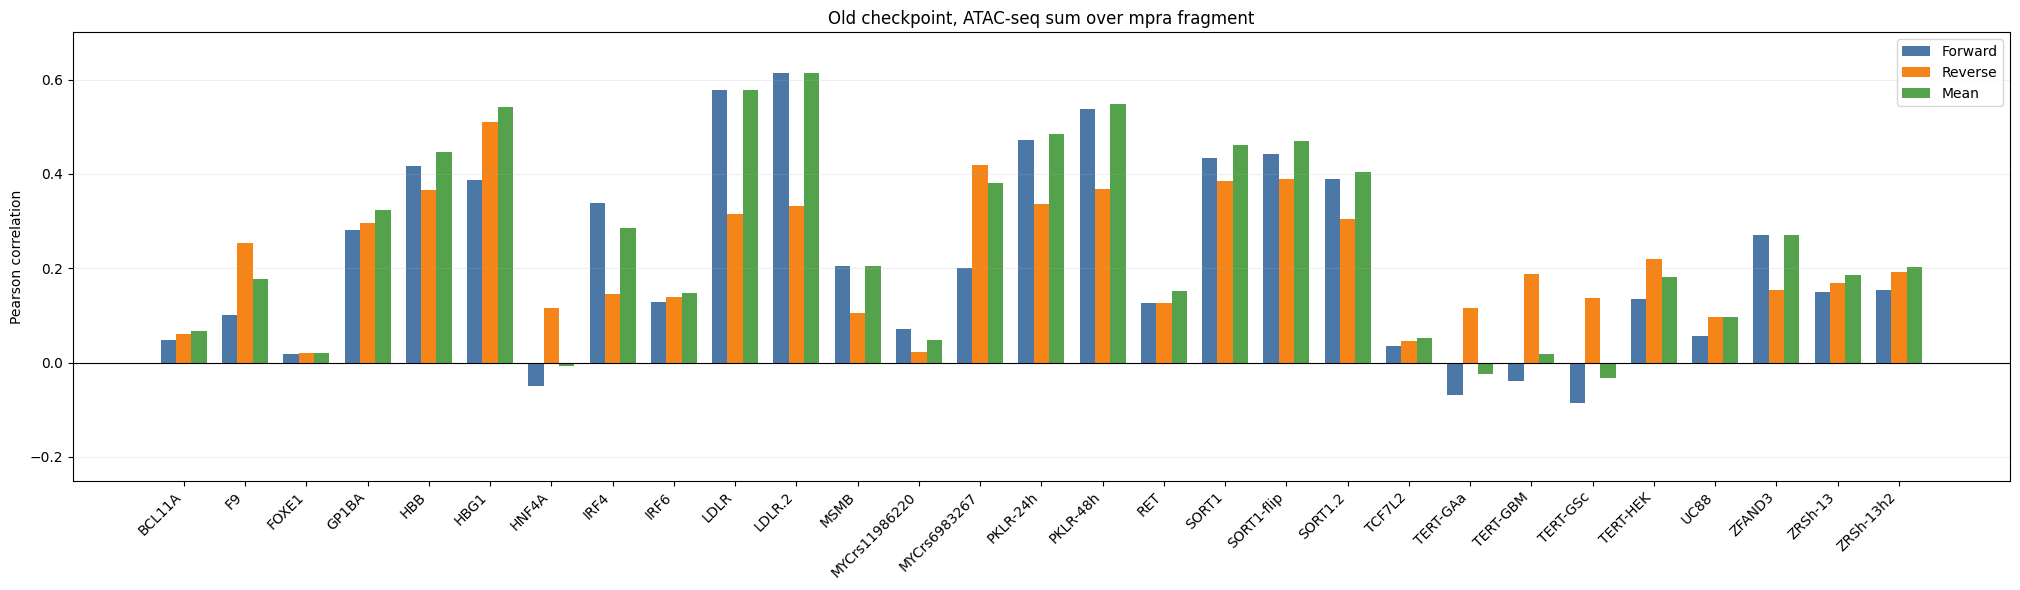

In [ ]:
plot_correlation_json('/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/results/forward_reverse_variant_api/track_feature_correlations.json', title='Old checkpoint, ATAC-seq sum over mpra fragment')

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl


def plot_true_vs_pred(
    df: pl.DataFrame,
    prediction_col: str,
    element: str,
    target_col: str = "Value",
):
    """Plot true values against predictions from one DataFrame column."""
    data = df.filter(pl.col.Element == element).select(target_col, prediction_col).drop_nulls()

    true = data[target_col].to_numpy()
    predicted = data[prediction_col].to_numpy()

    finite = np.isfinite(true) & np.isfinite(predicted)
    true = true[finite]
    predicted = predicted[finite]

    if len(true) == 0:
        raise ValueError("No finite true/predicted value pairs to plot.")

    fig, ax = plt.subplots(figsize=(6, 6))
    corr = np.round(np.corrcoef(true, predicted)[0, 1], decimals=2)
    ax.scatter(true, predicted, alpha=0.3, s=20)

    #lower = min(true.min(), predicted.min())
    #upper = max(true.max(), predicted.max())
    #ax.plot([lower, upper], [lower, upper], "--", color="gray")

    ax.set_xlabel(target_col)
    ax.set_ylabel(prediction_col)
    ax.set_title(f"True vs predicted: {prediction_col}, element: {element}, corr: {corr}")

    fig.tight_layout()
    return fig, ax

In [ ]:
new_checkpoint = pl.read_csv('/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/results/new_checkpoint_results/dataset_with_predictions.tsv', separator='\t', infer_schema_length=10000)

In [ ]:
new_checkpoint

Element,Cell_Type,Chromosome,Position,Ref,Alt,Tags,DNA,RNA,Value,P-Value,variant,expr_forward,expr_reverse,expr_mean,track_feature_forward,track_feature_reverse,track_feature_mean
str,str,str,i64,str,str,i64,i64,i64,f64,f64,str,f64,f64,f64,f64,f64,f64
"""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""-""",32,577,1345,-0.34,0.00546,"""chr2:60494939:C>-""",-0.014587,-0.013672,-0.01413,9.200195,-4.173828,2.513184
"""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""A""",146,2785,6772,-0.05,0.38889,"""chr2:60494939:C>A""",-0.009521,-0.009766,-0.009644,21.207031,-0.984375,10.111328
"""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""G""",60,975,2436,-0.13,0.13721,"""chr2:60494939:C>G""",-0.008118,0.009766,0.000824,11.739258,1.8046875,6.771973
"""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""T""",1084,8543,16057,-0.7,0.0,"""chr2:60494939:C>T""",-0.023483,0.003906,-0.009789,8.0859375,3.951172,6.018555
"""BCL11A""","""HEL92.1.7""","""2""",60494940,"""C""","""A""",596,9425,23430,-0.08,0.00413,"""chr2:60494940:C>A""",-0.002319,0.011719,0.0047,16.495117,6.324219,11.409668
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ZRSh-13h2""","""NIH-3T3""","""7""",156791601,"""G""","""T""",1676,12030,37310,0.1,0.00001,"""chr7:156791601:G>T""",-0.010742,-0.002686,-0.006714,-8.041016,-11.605469,-9.823242
"""ZRSh-13h2""","""NIH-3T3""","""7""",156791602,"""C""","""-""",1447,11717,34300,0.04,0.11224,"""chr7:156791602:C>-""",0.000488,0.019775,0.010132,-1.853516,4.667969,1.407227
"""ZRSh-13h2""","""NIH-3T3""","""7""",156791602,"""C""","""A""",25,107,309,-0.17,0.33374,"""chr7:156791602:C>A""",0.0,-0.004639,-0.002319,0.400391,-0.283203,0.058594


In [ ]:
old_checkpoint = pl.read_csv('/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/results/forward_reverse_variant_api/dataset_with_predictions.tsv', separator='\t', infer_schema_length=10000)

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'True vs predicted: score, element: HBG1, corr: -0.42'}, xlabel='Value', ylabel='score'>)

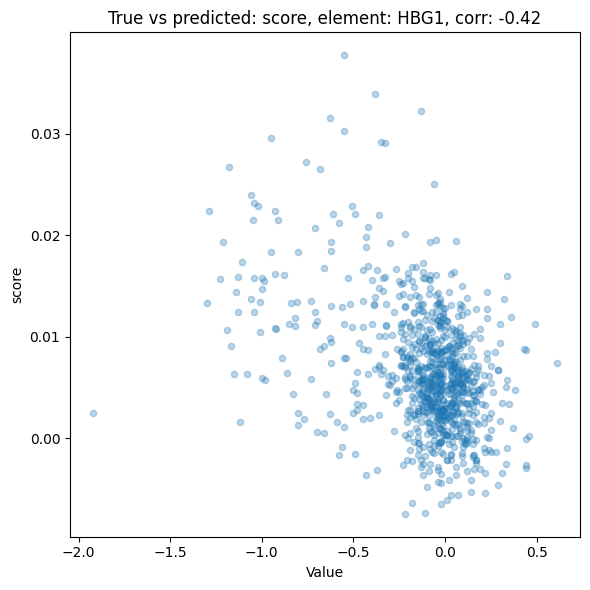

In [ ]:
plot_true_vs_pred(df=dataset_results, prediction_col='score', element='HBG1')

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'True vs predicted: track_feature_mean, element: SORT1, corr: 0.5'}, xlabel='Value', ylabel='track_feature_mean'>)

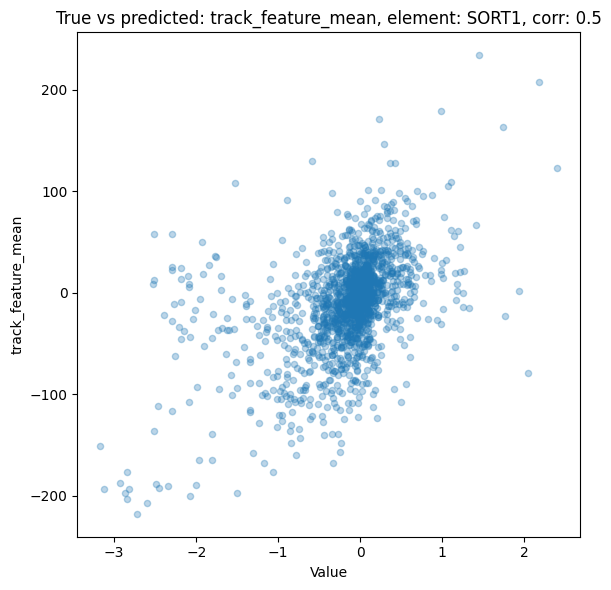

In [ ]:
plot_true_vs_pred(df=new_checkpoint, prediction_col='track_feature_mean', element='SORT1')

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'True vs predicted: expr_forward'}, xlabel='Value', ylabel='expr_forward'>)

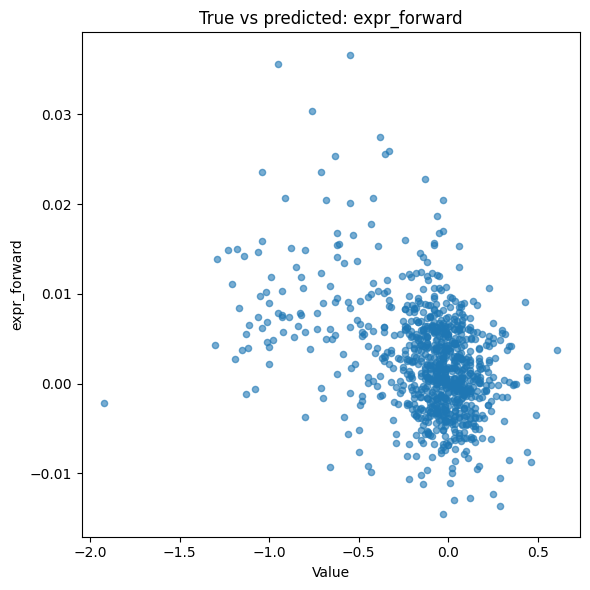

In [ ]:
plot_true_vs_pred(df=old_checkpoint, prediction_col='expr_forward', element='HBG1')